# Distributions

Interesting sources: 
- https://app.datacamp.com/learn/courses/foundations-of-probability-in-python

In [ ]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


# Uniform distribution

## Rolling a 6-sided die

![](https://wherethewindsblow.com/wp-content/uploads/2023/06/JUMBO-Six-sided-white-dice.jpg)

We are simulating the process of rolling a standard six-sided die. Each roll produces a random integer between 1 and 6, with all outcomes being equally likely. By generating multiple samples within this range, we can observe how the distribution of results begins to resemble a uniform distribution as the number of rolls increases.

In [3]:
minValue = 1 #  
maxValue = 6 # Maximum value of the dice
numberOfSamples = 6 # Increase number to show that it converges to a uniform distribution

Now we simulate rolling the die ```numberOfSamples``` times:
If you rerun the script you can see that the values change, just like a 'real' die.

In [31]:
import pandas as pd 
import numpy as np

results = pd.Series( np.random.randint(low=minValue, high=maxValue + 1, size=numberOfSamples) )
results

0    1
1    6
2    6
3    1
4    5
5    5
dtype: int32

<Axes: >

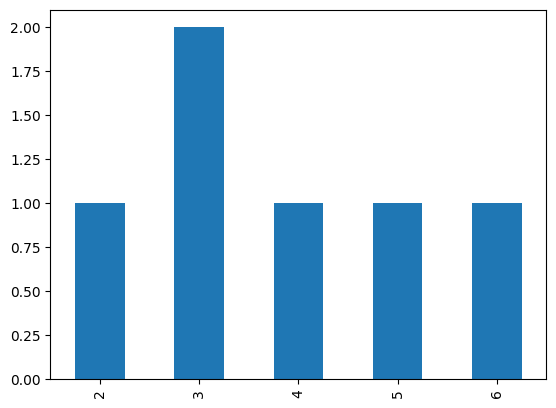

In [7]:
results.value_counts().sort_index().plot(kind='bar')

## Normal distribution

### Sampling from the average length of  a full-grown citizen in the Netherlands.

Mean = Median = Mode (all located in the center)

Symmetrical around the mean

Approximately:

- 68% of the values fall within 1 standard deviation of the mean
- 95% within 2 standard deviations
- 99.7% within 3 standard deviations

(This is known as the empirical rule or 68-95-99.7 rule)

In [8]:
averageLength = 174.25 # Average length of a person in cm
stdLength = 8 # Standard deviation of the length of a person in cm
numberOfPeopleToSample = 3000 # Play with these values to show the impact on the histogram

In [9]:
randomLengths = pd.Series( np.random.normal(averageLength, stdLength, numberOfPeopleToSample) )
randomLengths.head()

0    159.894525
1    172.634267
2    163.571724
3    183.380512
4    176.755823
dtype: float64

<Axes: ylabel='Frequency'>

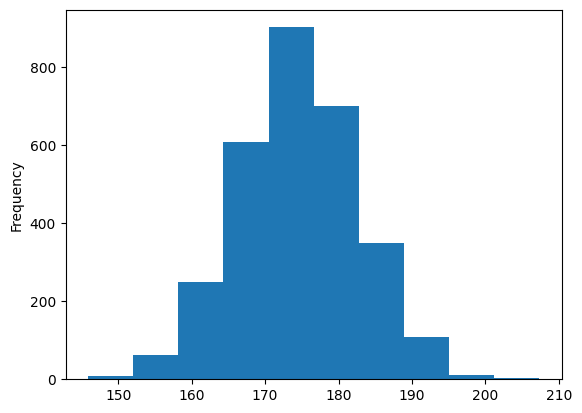

In [10]:
randomLengths.plot(kind='hist', bins=10)

![](https://upload.wikimedia.org/wikipedia/commons/8/8c/Standard_deviation_diagram.svg 'Normal distribution')

### Examples of normal distribution in real life
- https://studiousguy.com/real-life-examples-normal-distribution/
- https://galtonboard.com/probabilityexamplesinlife

### Central limit theorem

**What is the Central Limit Theorem?**
In simple terms:

If you take many random samples of a certain size from any population, and calculate the mean of each sample, then the distribution of those sample means will:
- Be approximately normal (bell-shaped)
- Have the same average as the original population
- Have a smaller spread (standard deviation gets smaller as sample size increases)
- Even if the original data is not normally distributed!

**Why is this useful?**
Because it lets us:
- Use normal distribution tools (like confidence intervals) on data that isn't normal
- Make predictions and inferences about population averages
- Justify why the mean is a reliable estimate with large samples



In [11]:
sampleMeans = []
sampleSize = 100
sampleMeansSize = 10000

for i in range(sampleMeansSize):
    randomLengths = pd.Series( np.random.normal(averageLength, stdLength, sampleSize) ) 
    sampleMeans.append(randomLengths.mean()) 

In [12]:
sampleMeans

[np.float64(173.93568085597772),
 np.float64(175.55178678566216),
 np.float64(174.1778386014695),
 np.float64(173.93022572176224),
 np.float64(173.03575928724396),
 np.float64(173.3186819349655),
 np.float64(174.37498786602308),
 np.float64(174.0449295641256),
 np.float64(175.7880811784662),
 np.float64(174.66086708033242),
 np.float64(174.3184613917096),
 np.float64(173.93141805403),
 np.float64(174.3118963694304),
 np.float64(174.231339698363),
 np.float64(174.93989174818472),
 np.float64(172.6435901210988),
 np.float64(174.41750486782547),
 np.float64(174.97980735626805),
 np.float64(173.85729864801652),
 np.float64(175.08635456050564),
 np.float64(174.2746482331656),
 np.float64(174.46039201146198),
 np.float64(174.6956839397396),
 np.float64(174.92398067209913),
 np.float64(174.06623065704557),
 np.float64(172.92787479421844),
 np.float64(174.44631246574292),
 np.float64(174.11123188320641),
 np.float64(173.15323885542242),
 np.float64(174.85384052318474),
 np.float64(173.72753204

<Axes: ylabel='Frequency'>

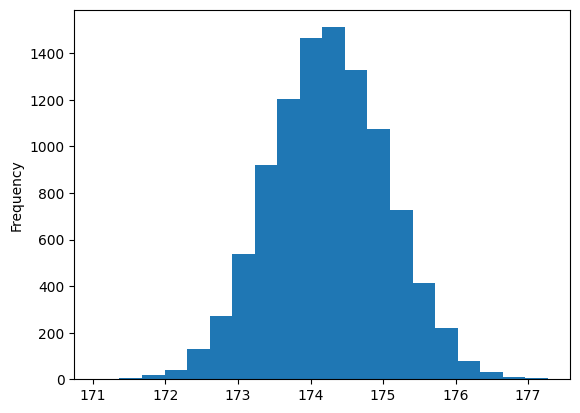

In [13]:
pd.Series(sampleMeans).plot(kind='hist', bins = 20)

In [28]:
sampleMeans = []
sampleSize = 100
sampleMeansSize = 10000

for i in range(sampleMeansSize):
    randomRolls = pd.Series( np.random.randint(low=minValue, high=maxValue + 1, size=sampleSize) )
    sampleMeans.append(randomRolls.mean())

<Axes: ylabel='Frequency'>

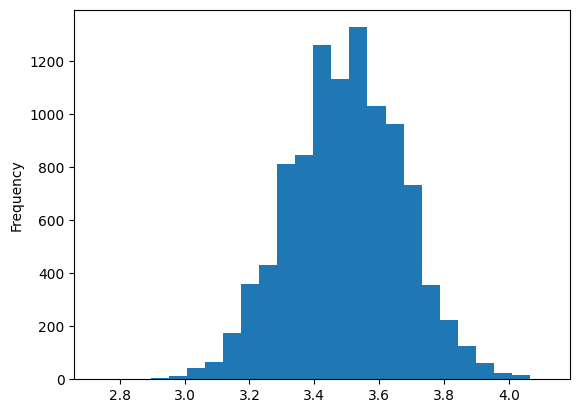

In [29]:
pd.Series(sampleMeans).plot(kind='hist', bins = 25)

### Confidence interval

**What is a Confidence Interval?**
A confidence interval is a range of values that we believe is likely to contain the true population parameter (like the mean or proportion), based on a sample.

Usually, we talk about the **mean**, so let’s focus on that:

A 95% confidence interval for the mean says:
“We are 95% confident that the true population mean lies within this range.”


![](https://datatab.net/assets/tutorial/confidence_interval.png)

![](https://datatab.net/assets/tutorial/Confidence_interval_formula.png)

So let's reconsider one sample. Based on this one sample, what can we say about the mean of the underlying population?

In [16]:
import scipy.stats as st
confidence = 0.95
st.t.interval(confidence, len(randomLengths)-1, loc=randomLengths.mean(), scale=st.sem(randomLengths))

(np.float64(172.3832669580394), np.float64(175.84544788472746))

And how about rolling a dice?

In [17]:
import scipy.stats as st
confidence = 0.95
st.t.interval(confidence, len(randomRolls)-1, loc=randomRolls.mean(), scale=st.sem(randomRolls))

(np.float64(2.8735803333780963), np.float64(3.5464196666219037))

Let's apply this to the iris dataset. What is the 95% confidence interval of the sepal_length? Meaning, let's calculate the interval that contains the real mean sepal length with 95% confidence.

In [18]:
import seaborn as sns
iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [20]:
import scipy.stats as st
confidence = 0.98
st.t.interval(confidence, len(iris)-1, loc=iris['sepal_length'].mean(), scale=st.sem(iris['sepal_length']))

(np.float64(5.684336202790978), np.float64(6.00233046387569))

### Portfolio assignment 7
15 min: Look at the histogram of at least 2 columns with numerical data in the dataset that you chose in portfolio assignment 4. Do you recognise the distribution? Does it look like a uniform or normal distribution or something else? If it doesn't look like a uniform or normal distribution, take a quick look here to see if you can find the distribution shape: https://www.itl.nist.gov/div898/handbook/eda/section3/eda366.htm


<Axes: ylabel='Frequency'>

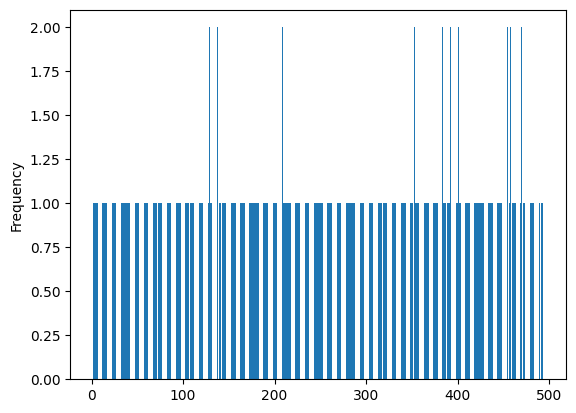

In [55]:
import matplotlib.pyplot as plt
rank = topRatedAnime['rank'].dropna()

rank.plot(kind='hist', bins=1000)


<Axes: ylabel='Frequency'>

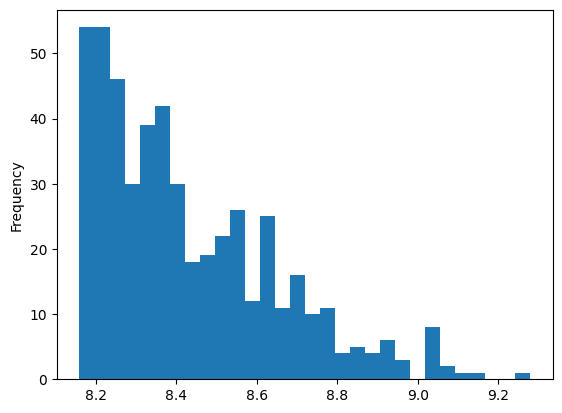

In [54]:
import matplotlib.pyplot as plt
score = topRatedAnime['score'].dropna()

score.plot(kind='hist', bins=30)

![](https://i.imgur.com/0v1CGNV.png)<br>
Findings: ...<br>

### Portfolio assignment 8
15 min: 
- Calculate the 90%, 95%, 99% and 99.99% confidence interval for at least 2 columns with numerical data in the dataset that you chose in portfolio assignment 4. Do you see the impact the confidence has on the interval?
- Now calculate the 95% confidence interval again but use only the first 10% of your rows. Compare this interval to the previous 95% confidence interval you calculated. Do you see the impact of having less data?

In [56]:
import scipy.stats as st
confidence = 0.90
st.t.interval(confidence, len(topRatedAnime)-1, loc=topRatedAnime['score'].mean(), scale=st.sem(topRatedAnime['score']))

(np.float64(8.412534766508976), np.float64(8.445345233491022))

In [57]:
import scipy.stats as st
confidence = 0.95
st.t.interval(confidence, len(topRatedAnime)-1, loc=topRatedAnime['score'].mean(), scale=st.sem(topRatedAnime['score']))

(np.float64(8.409380809243201), np.float64(8.448499190756797))

In [58]:
import scipy.stats as st
confidence = 0.98
st.t.interval(confidence, len(topRatedAnime)-1, loc=topRatedAnime['score'].mean(), scale=st.sem(topRatedAnime['score']))

(np.float64(8.40570621519587), np.float64(8.452173784804128))

In [81]:
import scipy.stats as st
confidence = 0.95
n_rows = max(1, int(len(topRatedAnime) * 0.10))
st.t.interval(confidence, len(topRatedAnime.iloc[:n_rows]['score'].dropna())-1, loc=topRatedAnime.iloc[:n_rows]['score'].dropna().mean(), scale=st.sem(topRatedAnime.iloc[:n_rows]['score'].dropna()))

(np.float64(8.863321399639794), np.float64(8.936278600360207))

In [73]:
import scipy.stats as st
confidence = 0.90
st.t.interval(confidence, len(topRatedAnime)-1, loc=topRatedAnime['popularity'].mean(), scale=st.sem(topRatedAnime['popularity']))

(np.float64(1417.9775797398056), np.float64(1700.8824202601945))

In [74]:
import scipy.stats as st
confidence = 0.95
st.t.interval(confidence, len(topRatedAnime)-1, loc=topRatedAnime['popularity'].mean(), scale=st.sem(topRatedAnime['popularity']))

(np.float64(1390.7829111064543), np.float64(1728.0770888935458))

In [75]:
import scipy.stats as st
confidence = 0.98
st.t.interval(confidence, len(topRatedAnime)-1, loc=topRatedAnime['popularity'].mean(), scale=st.sem(topRatedAnime['popularity']))

(np.float64(1359.0991059504431), np.float64(1759.760894049557))

In [82]:
import scipy.stats as st
confidence = 0.95
n_rows = max(1, int(len(topRatedAnime) * 0.10))
st.t.interval(confidence, len(topRatedAnime.iloc[:n_rows]['popularity'].dropna())-1, loc=topRatedAnime.iloc[:n_rows]['popularity'].dropna().mean(), scale=st.sem(topRatedAnime.iloc[:n_rows]['popularity'].dropna()))

(np.float64(388.64351511529424), np.float64(823.8364848847058))

![](https://i.imgur.com/0v1CGNV.png)<br>
Assumptions: ...<br>
Findings: ...<br>

In [21]:
import pandas as pd
topRatedAnime = pd.read_csv('top_anime_dataset.csv', sep=',')
topRatedAnime.head()

,mal_id,title,title_english,type,source,episodes,status,airing,rating,score,scored_by,rank,popularity,members,favorites,synopsis,year,genres,studios,url
0,52991,Sousou no Frieren,Frieren: Beyond Journey's End,TV,Manga,28.0,Finished Airing,False,PG-13 - Teens 13 or older,9.28,823434,1.0,108,1353494,85889,During their decade-long quest to defeat the D...,2023.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/52991/Sousou_no_...
1,59978,Sousou no Frieren 2nd Season,Frieren: Beyond Journey's End Season 2,TV,Manga,10.0,Currently Airing,True,PG-13 - Teens 13 or older,9.16,62148,2.0,644,414180,5476,"Following the First-Class Mage Exam, the trio—...",2026.0,"Adventure, Drama, Fantasy",Madhouse,https://myanimelist.net/anime/59978/Sousou_no_...
2,5114,Fullmetal Alchemist: Brotherhood,Fullmetal Alchemist: Brotherhood,TV,Manga,64.0,Finished Airing,False,R - 17+ (violence & profanity),9.11,2290193,3.0,3,3645704,240910,After a horrific alchemy experiment goes wrong...,2009.0,"Action, Adventure, Drama, Fantasy",Bones,https://myanimelist.net/anime/5114/Fullmetal_A...
3,57555,Chainsaw Man Movie: Reze-hen,Chainsaw Man – The Movie: Reze Arc,Movie,Manga,1.0,Finished Airing,False,R - 17+ (violence & profanity),9.09,255607,4.0,643,414906,12097,Despite the immediate challenges following bec...,NaN,"Action, Fantasy",MAPPA,https://myanimelist.net/anime/57555/Chainsaw_M...
4,9253,Steins;Gate,Steins;Gate,TV,Visual novel,24.0,Finished Airing,False,PG-13 - Teens 13 or older,9.07,1508032,5.0,14,2786505,201170,Eccentric scientist Rintarou Okabe has a never...,2011.0,"Drama, Sci-Fi, Suspense",White Fox,https://myanimelist.net/anime/9253/Steins_Gate
